In [1]:
%matplotlib inline
import matplotlib
from matplotlib import pyplot as plt
import numpy as np
import pandas as pd 

plt.rcParams['figure.figsize']=[10.0,8.0]
plt.rcParams.update({'font.size': 14})

In [2]:
from scipy.integrate import dblquad
from scipy.optimize import curve_fit
from scipy.interpolate import interp1d

## Numerical Integration of $\delta t$ Correlator

In [3]:
I = lambda t, r: 8*np.pi*(np.exp(t/2) + np.exp(-t/2) + (t**2-(r**2+4*r))*np.exp(-r/2)/(4*r))

dtdts = lambda t, r: ((2*np.pi*np.exp(-r/2))/(r*I(t,r)))*(r**2/4+r+2-t**2/4)*((np.log(I(t,r)/(8*np.pi)))**2-t**2/4+np.pi**2/6)
dtdtd = lambda t, r: ((16*np.pi**2)/I(t,r)**2)*(4-np.exp(-t/2-r/2)/(2*r)*(r+t+4)*(r-t)-np.exp(t/2-r/2)/(2*r)*(r-t+4)*(r+t)+np.exp(-r)/(16*r**2)*((r+4)**2-t**2)*(r**2-t**2))*((np.log(I(t,r)/(8*np.pi))-1)**2-t**2/4+np.pi**2/6-1)

dtdt = lambda t, r: dtdts(t,r) + dtdtd(t,r)

func = lambda t, r, k: (k**3/(2*np.pi**2))*(4*np.pi*r**2)*np.sin(k*r)/(k*r)*dtdt(t,r)

In [4]:
# k = np.logspace(-2,1,1000)
# P = np.zeros(len(k))

# for n in range(len(k)):
#     P[n] = dblquad(func, 1e-3, 1e2, lambda r:-r, lambda r: r, args=(k[n],))[0]
    
# df = pd.DataFrame({'k/beta': k, 'P(k/beta)':P})
# df.to_csv('PowerSpecInt.csv',index=False)

## Curve Fit to Numerical Integration Result

In [5]:
df = pd.read_csv('PowerSpecInt.csv')
k = df['k/beta'].to_numpy()
P = df['P(k/beta)'].to_numpy()

In [6]:
fit = lambda k, X,Y, c1, c2, c3, c4, c5, c6, c7, const: Y/((X*k)**-3 + c1*(X*k)**-1.01 + c2*(X*k)**-0.25 + c3*(X*k)**0.5 + c4*(X*k)**0.9 + c5*(X*k)**1.6 + c6*(X*k)**2.07 + c7*(X*k)**3.05 +const) #fix asymptotic behavior, fit intermediate curvy region


popt, pcov = curve_fit(fit,k,P,p0=[2.72244403,3.47164535,2.46421579,-10.1236776,3.43619141,-10.05829138,8.23106432,-3.51839146,0.37987371,11.86932779])
popt

C:\Users\DAVENH~1\AppData\Local\Temp/ipykernel_12756/2960998729.py:1: RuntimeWarning: invalid value encountered in power
  fit = lambda k, X,Y, c1, c2, c3, c4, c5, c6, c7, const: Y/((X*k)**-3 + c1*(X*k)**-1.01 + c2*(X*k)**-0.25 + c3*(X*k)**0.5 + c4*(X*k)**0.9 + c5*(X*k)**1.6 + c6*(X*k)**2.07 + c7*(X*k)**3.05 +const) #fix asymptotic behavior, fit intermediate curvy region
C:\Users\DAVENH~1\AppData\Local\Temp/ipykernel_12756/2960998729.py:1: RuntimeWarning: invalid value encountered in sqrt
  fit = lambda k, X,Y, c1, c2, c3, c4, c5, c6, c7, const: Y/((X*k)**-3 + c1*(X*k)**-1.01 + c2*(X*k)**-0.25 + c3*(X*k)**0.5 + c4*(X*k)**0.9 + c5*(X*k)**1.6 + c6*(X*k)**2.07 + c7*(X*k)**3.05 +const) #fix asymptotic behavior, fit intermediate curvy region


array([  2.72244403,   3.47164535,   2.46421579, -10.1236776 ,
         3.43619141, -10.05829138,   8.23106432,  -3.51839146,
         0.37987371,  11.86932779])

In [7]:
interpol = interp1d(k,P)

In [8]:
#popt

In [9]:
kpeak = df['k/beta'][df['P(k/beta)'] == df['P(k/beta)'].max()]
kpeak

564    0.493962
Name: k/beta, dtype: float64

In [10]:
low = 0.3
upp = 0.8

$P_{PT}(k) = \dfrac{A}{(ak)^{-3} + c_1(ak)^{-1.01} +c_2(ak)^{-0.25}+c_3(ak)^{0.5}+c_4(ak)^{0.9}+c_5(ak)^{1.6}+c_6(ak)^{2.07}+c_7(ak)^{3.05}+ b}$

$a = 2.72244403\\ A = 3.47164535\\c_1 = 2.46421579\\c_2 = -10.1236776\\c_3 = 3.43619141\\c_4 = -10.05829138\\c_5 = 8.23106432\\c_6 = -3.51839146\\c_7 = 0.37987371\\b = 11.86932779$

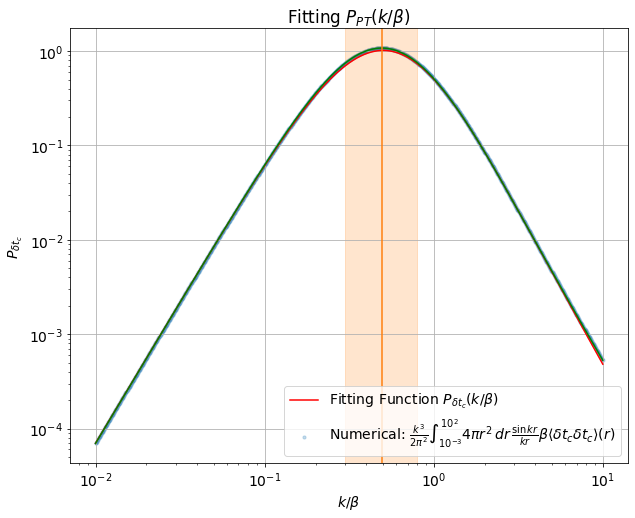

In [11]:
plt.scatter(k,P,s=10,marker='o',alpha=0.25, label=r'Numerical: $\frac{k^3}{2\pi^2}\int_{10^{-3}}^{10^2}4\pi r^2 \, dr \, \frac{\sin{kr}}{kr} \beta \left< \delta t_c \delta t_c \right>(r)$')

plt.plot(k,fit(k,popt[0],popt[1],popt[0],popt[3],popt[4],popt[5],popt[6],popt[7],popt[8],popt[9]),c='r', label=r'Fitting Function $P_{\delta t_c}(k/\beta)$')

# plt.plot(k,fit(k,2.15427971,  6.96140214,  2.69864292, -0.97120367,  1.21613975, 1.20284452,  1.12187156,  1.20287349,  0.46460509,  3.1, 0.1,3.65))

plt.plot(k,interpol(k),c='g')

plt.axvline(0.493962,c='C1')
plt.axvspan(low,upp,alpha=0.2,color='C1')

plt.xscale('log')
plt.yscale('log')

plt.xlabel(r'$k/\beta$')
plt.ylabel(r'$P_{\delta t_c}$')
plt.title(r'Fitting $P_{PT}(k/\beta)$')

plt.grid(True)
plt.legend()
plt.savefig('PkFit.jpg')

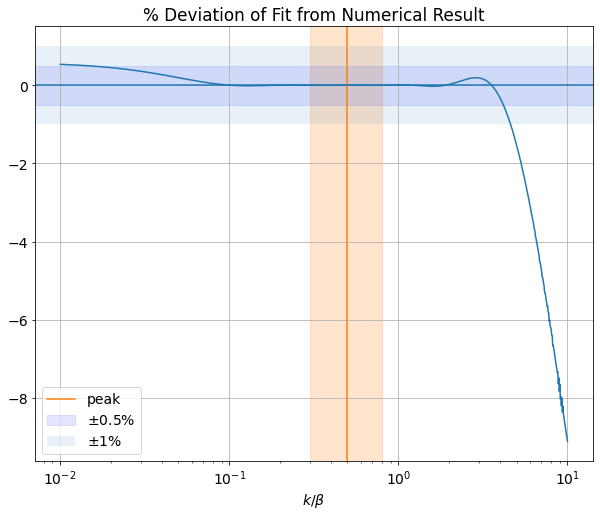

In [12]:
plt.plot(df['k/beta'],(fit(df['k/beta'],popt[0],popt[1],popt[2],popt[3],popt[4],popt[5],popt[6],popt[7],popt[8],popt[9])-df['P(k/beta)'])/df['P(k/beta)']*100)

# plt.plot(df['k/beta'],(interpol(df['k/beta'])-df['P(k/beta)'])/df['P(k/beta)']*100, c='g')


plt.axvline(0.493962,c='C1',label='peak')
plt.axvspan(low,upp,alpha=0.2,color='C1')

plt.axhline(0)
plt.axhspan(-0.5,0.5,alpha=0.1,color='b',label=r'$\pm 0.5\%$')
plt.axhspan(-1,1,alpha=0.1,label=r'$\pm 1\%$')

plt.xlabel(r'$k/\beta$')
plt.title('% Deviation of Fit from Numerical Result')

plt.legend()
plt.xscale('log')
plt.grid(True)

plt.savefig('PkFit_Deviate.jpg')

In [13]:
# chi square 
np.sum((fit(k,popt[0],popt[1],popt[2],popt[3],popt[4],popt[5],popt[6],popt[7],popt[8],popt[9])-P)**2)

1.0596074926536982e-06

## Rescale Curve by PT Parameters

In [14]:
pk = lambda k: fit(k,popt[0],popt[1],popt[2],popt[3],popt[4],popt[5],popt[6],popt[7],popt[8],popt[9])
# pk = interpol

In [15]:
dfbgd = pd.read_csv('bgd.csv')
dfbgd['1:z']
dfbgd['4:H [1/Mpc]']

H = interp1d(dfbgd['1:z'],dfbgd['4:H [1/Mpc]']) # for MCMC scan, call from CLASS for given time step?

In [16]:
def Pk(k, zPT, fDR, fPT): 
    
    # adiabatic part from CLASS
    kpivot = 0.05
    As = 2.100549e-9
    ns = 0.9660499
    
    aPT = 1/(1+zPT)
    
    return fDR**2*fPT**2*pk(k*fPT/(aPT*H(zPT))) + As*(k/kpivot)**(ns - 1) ### TYPO! no factor 1/4 infront since fDR -> 2fDR
     

In [42]:
def Pk_iso(k,A,k0):
    
    kpivot = 0.05
    As = 2.100549e-9
    ns = 0.9660499
    
    if k<=k0:
        return A * (k/k0)**3 + As*(k/kpivot)**(ns - 1)
    else:
        return A + As*(k/kpivot)**(ns - 1)
    
Pk_iso = np.vectorize(Pk_iso)

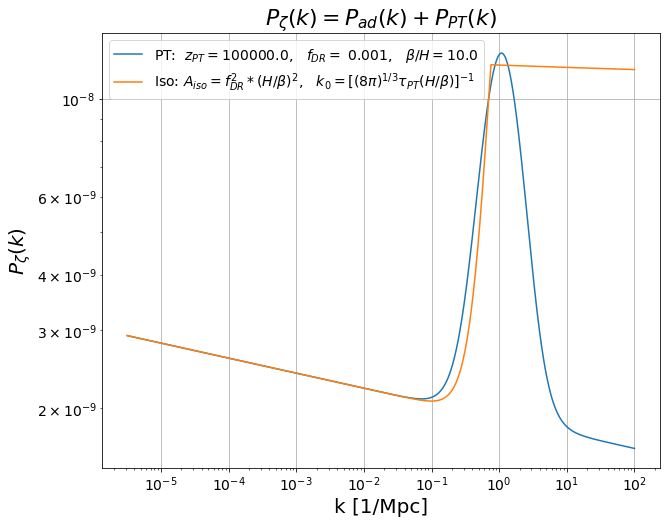

In [43]:
k = np.logspace(-5.5,2,10000)

fDR = 0.001
fPT = 0.1 # i.e. H_PT/beta
zPT = 1e5

aPT = 1/(1+zPT)
Aiso = (fDR*fPT)**2
k0 = (aPT*H(zPT))/(fPT*(8*np.pi)**(1/3))


plt.plot(k, Pk(k, zPT,    fDR,    fPT   ), label=r'PT:  $z_{PT} = $'+str(zPT)+r',   $f_{DR} = $ '+str(fDR)+r',   $\beta/H = $'+str(1/fPT))
# plt.plot(k, Pk(k, zPT*10, fDR,    fPT   ), label=r'$z_{PT} = 10^5$, $f_{DR} = 0.01$, $\beta/H = 10$')
# plt.plot(k, Pk(k, zPT,    fDR*5,  fPT   ), label=r'$z_{PT} = 10^4$, $f_{DR} = 0.05$, $\beta/H = 10$')
# plt.plot(k, Pk(k, zPT,    fDR,    fPT/10), label=r'$z_{PT} = 10^4$, $f_{DR} = 0.01$, $\beta/H = 100$')

plt.plot(k,Pk_iso(k,Aiso,k0), label=r'Iso: $A_{iso} = f_{DR}^2*(H/\beta)^2$,   $k_0 = [(8\pi)^{1/3}\tau_{PT}(H/\beta)]^{-1}$')

plt.xscale('log')
plt.yscale('log')
# plt.ylim([1e-9,5e-6])

plt.title(r'$P_\zeta(k) = P_{ad}(k) + P_{PT}(k)$',fontsize=22)
plt.xlabel(r'k [1/Mpc]',fontsize=20)
plt.ylabel(r'$P_\zeta(k)$',fontsize=20)

plt.grid(True)
plt.legend(loc='upper left')

plt.savefig('PowerSpec.jpg')

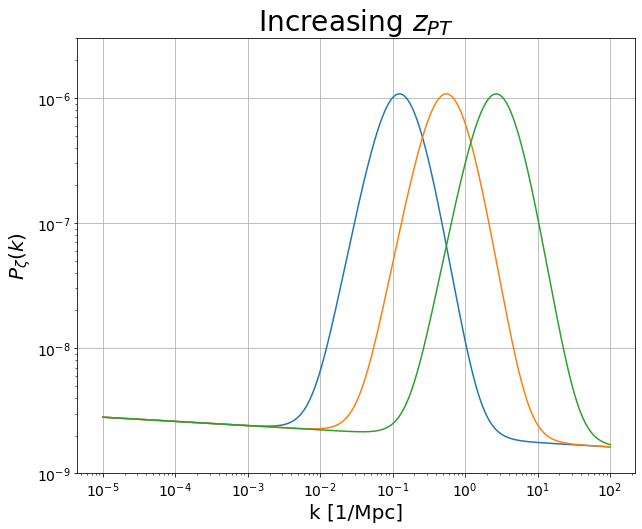

In [44]:
k = np.logspace(-5,2,10000)

fDR = 0.01
fPT = 0.1 # i.e. H_PT/beta
zPT = 1e4


plt.plot(k, Pk(k, zPT,    fDR,  fPT   ), label=r'$z_{PT} = 10^4$, $f_{DR} = 0.01$, $\beta/H = 10$')
plt.plot(k, Pk(k, zPT*5, fDR,  fPT   ), label=r'$z_{PT} = 10^5$, $f_{DR} = 0.01$, $\beta/H = 10$')
plt.plot(k, Pk(k, zPT*25,    fDR,  fPT   ), label=r'$z_{PT} = 10^4$, $f_{DR} = 0.05$, $\beta/H = 10$')

plt.xscale('log')
plt.yscale('log')

plt.ylim([1e-9,3e-6])

plt.title(r'Increasing $z_{PT}$',fontsize=28)
plt.xlabel(r'k [1/Mpc]',fontsize=20)
plt.ylabel(r'$P_\zeta(k)$',fontsize=20)

plt.grid(True)
# plt.legend()

plt.savefig('PowerSpec_zPT.jpg')

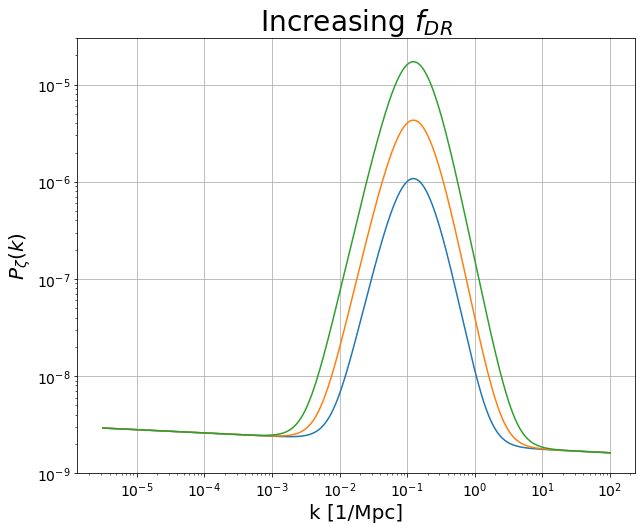

In [20]:
k = np.logspace(-5.5,2,10000)

fDR = 0.01
fPT = 0.1 # i.e. H_PT/beta
zPT = 1e4


plt.plot(k, Pk(k, zPT, fDR,    fPT), label=r'$z_{PT} = 10^4$, $f_{DR} = 0.01$, $\beta/H = 10$')
plt.plot(k, Pk(k, zPT, fDR*2,  fPT), label=r'$z_{PT} = 10^5$, $f_{DR} = 0.01$, $\beta/H = 10$')
plt.plot(k, Pk(k, zPT, fDR*4,  fPT), label=r'$z_{PT} = 10^4$, $f_{DR} = 0.05$, $\beta/H = 10$')

plt.ylim([1e-9,3e-5])
plt.xscale('log')
plt.yscale('log')

plt.title(r'Increasing $f_{DR}$',fontsize=28)
plt.xlabel(r'k [1/Mpc]',fontsize=20)
plt.ylabel(r'$P_\zeta(k)$',fontsize=20)

plt.grid(True)
# plt.legend()

plt.savefig('PowerSpec_fDR.jpg')

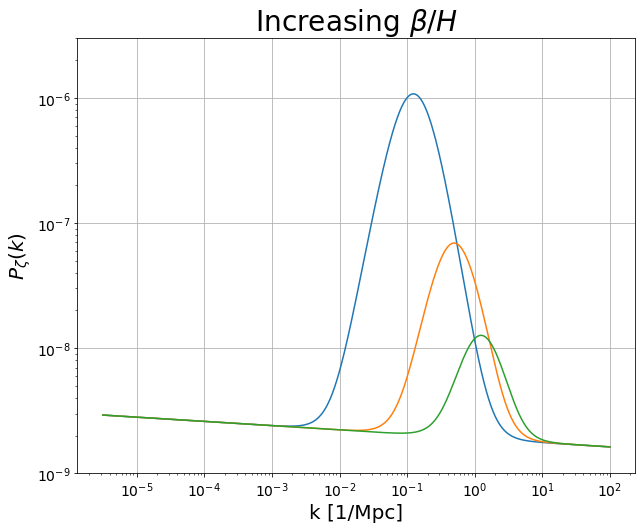

In [21]:
k = np.logspace(-5.5,2,10000)

fDR = 0.01
fPT = 0.1 # i.e. H_PT/beta
zPT = 1e4


plt.plot(k, Pk(k, zPT, fDR, fPT), label=r'$z_{PT} = 10^4$, $f_{DR} = 0.01$, $\beta/H = 10$')
plt.plot(k, Pk(k, zPT, fDR, fPT/4), label=r'$z_{PT} = 10^5$, $f_{DR} = 0.01$, $\beta/H = 10$')
plt.plot(k, Pk(k, zPT, fDR, fPT/10), label=r'$z_{PT} = 10^4$, $f_{DR} = 0.05$, $\beta/H = 10$')

plt.ylim([1e-9,3e-6])
plt.xscale('log')
plt.yscale('log')

plt.title(r'Increasing $\beta/H$',fontsize=28)
plt.xlabel(r'k [1/Mpc]',fontsize=20)
plt.ylabel(r'$P_\zeta(k)$',fontsize=20)

plt.grid(True)
# plt.legend()

plt.savefig('PowerSpec_betaH.jpg')

## Modify for generalized redshift

In [22]:
def fQ_mod(k, fDR, tauPT, Q):  # modified fDR with redshift factor 
    
    def kscale(k,tauPT,Q):
        if k*tauPT <= 1:
            return (k*tauPT)**(-Q)
        else:
            return 1
    
    kscale = np.vectorize(kscale)
    
    return fDR/(fDR + (1-fDR)*(4/(4+Q))*kscale(k,tauPT,Q))
    

def Pk_gen(k, zPT, fDR, fPT, Q): 
    
    # adiabatic part from CLASS
    kpivot = 0.05
    As = 2.100549e-9
    ns = 0.9660499
    
    aPT = 1/(1+zPT)
    tauPT = 1/(aPT*H(zPT))
    
    return fQ_mod(k, fDR, tauPT, Q)**2 * fPT**2 * pk(k*tauPT*fPT) #+ As*(k/kpivot)**(ns - 1) 


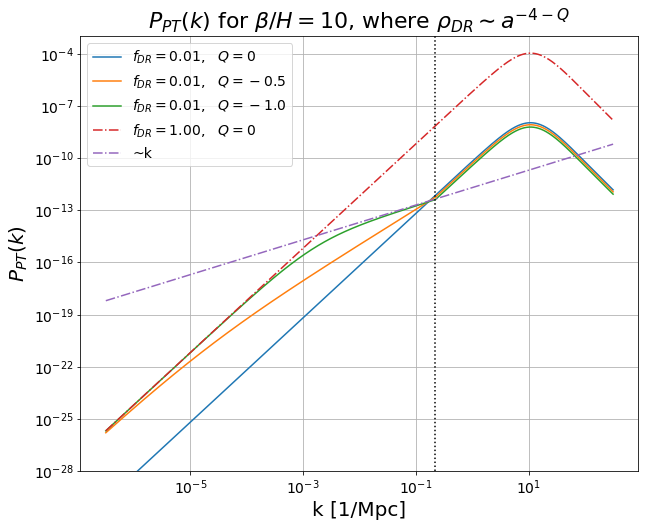

In [23]:
k = np.logspace(-6.5,2.5,10000)

fDR = 0.01
fPT = 0.01 # i.e. H_PT/beta
zPT = 1e5

aPT = 1/(1+zPT)
tauPT = 1/(aPT*H(zPT))

plt.plot(k, Pk_gen(k, zPT, fDR, fPT,  0     ) , label=r'$f_{DR} = 0.01$,   $Q= 0$')
plt.plot(k, Pk_gen(k, zPT, fDR, fPT, -0.50  ) , label=r'$f_{DR} = 0.01$,   $Q=-0.5$')
plt.plot(k, Pk_gen(k, zPT, fDR, fPT, -1.00  ) , label=r'$f_{DR} = 0.01$,   $Q=-1.0$')

plt.plot(k, Pk_gen(k, zPT, 1  , fPT,  0  ) , ls='-.',label=r'$f_{DR} = 1.00$,   $Q=0$')

plt.plot(k,2e-12*k,ls='-.',label=r'~k')

plt.axvline(1/tauPT,c='k',ls=':')

plt.xscale('log')
plt.yscale('log')
plt.ylim([1e-28,1e-3])

plt.title(r'$P_{PT}(k)$ for $\beta/H = 10$, where $\rho_{DR} \sim a^{-4-Q}$',fontsize=22)
plt.xlabel(r'k [1/Mpc]',fontsize=20)
plt.ylabel(r'$P_{PT}(k)$',fontsize=20)

plt.grid(True)
plt.legend(loc='upper left')

plt.savefig('Pkgen_lowredshift.jpg')

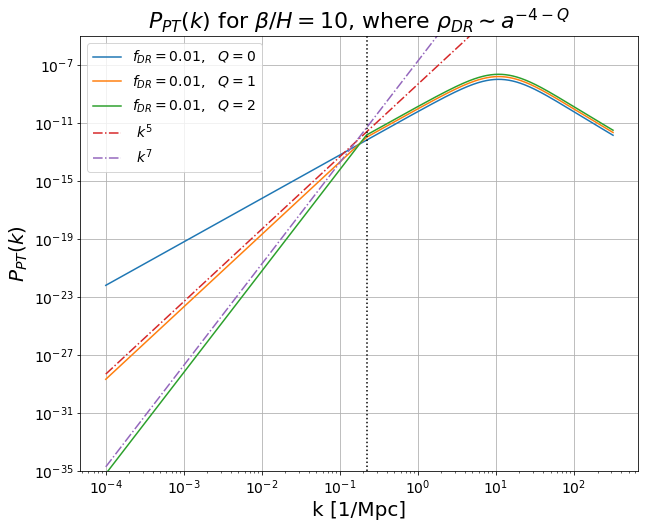

In [24]:
k = np.logspace(-4,2.5,10000)

fDR = 0.01
fPT = 0.01 # i.e. H_PT/beta
zPT = 1e5

aPT = 1/(1+zPT)
tauPT = 1/(aPT*H(zPT))

plt.plot(k, Pk_gen(k, zPT, fDR, fPT, 0     ) , label=r'$f_{DR} = 0.01$,   $Q=0$')
plt.plot(k, Pk_gen(k, zPT, fDR, fPT, 1.00  ) , label=r'$f_{DR} = 0.01$,   $Q=1$')
plt.plot(k, Pk_gen(k, zPT, fDR, fPT, 2.00  ) , label=r'$f_{DR} = 0.01$,   $Q=2$')

plt.plot(k,5e-9*k**5,ls='-.',label=r'$~k^5$')
plt.plot(k,2e-7*k**7,ls='-.',label=r'$~k^7$')

plt.axvline(1/tauPT,c='k',ls=':')

plt.xscale('log')
plt.yscale('log')
plt.ylim([1e-35,1e-5])

plt.title(r'$P_{PT}(k)$ for $\beta/H = 10$, where $\rho_{DR} \sim a^{-4-Q}$',fontsize=22)
plt.xlabel(r'k [1/Mpc]',fontsize=20)
plt.ylabel(r'$P_{PT}(k)$',fontsize=20)

plt.grid(True)
plt.legend(loc='upper left')

plt.savefig('Pkgen_highredshift.jpg')